<a href="https://colab.research.google.com/github/ansu555/ml_lab/blob/main/liner_regression(_Housing).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Housing - Housing.csv to Housing - Housing.csv


**Step 2: Load & Clean Data**

In [ ]:
import pandas as pd

df = pd.read_csv("Housing - Housing.csv")
df.dropna(inplace=True)

# Use only numeric features for simplicity
df = df[['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']]
df.head()


,price,area,bedrooms,bathrooms,stories,parking
0,13300000,7420,4,2,3,2
1,12250000,8960,4,4,4,3
2,12250000,9960,3,2,2,2
3,12215000,7500,4,2,2,3
4,11410000,7420,4,1,2,2


**Step 3: Preprocessing, Gradient Descent, Evaluation**

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Preprocessing
def preprocess(df, target):
    X = df.drop(columns=[target])
    y = df[target].values.reshape(-1, 1)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled = np.c_[np.ones((X_scaled.shape[0], 1)), X_scaled]  # bias
    return X_scaled, y, scaler, X.columns.tolist()

# Gradient Descent
def gradient_descent(X, y, alpha=0.01, epochs=10000, tol=1e-6):
    m, n = X.shape
    theta = np.zeros((n, 1))
    prev_cost = float('inf')
    for i in range(epochs):
        pred = X @ theta
        error = pred - y
        cost = (1 / (2 * m)) * np.sum(error**2)
        if abs(prev_cost - cost) < tol:
            print(f"✅ Converged at iteration {i}")
            break
        prev_cost = cost
        gradient = (1 / m) * (X.T @ error)
        theta -= alpha * gradient
    return theta, cost

# Evaluation
def evaluate(X, y, theta):
    pred = X @ theta
    score = r2_score(y, pred)
    print(f"🔍 R² Score: {score:.4f} ({score * 100:.2f}% accuracy)")
    return pred

# Print hypothesis
def print_hypothesis(theta, features):
    terms = [f"{theta[0][0]:.2f}"]
    for i, f in enumerate(features):
        terms.append(f"{theta[i+1][0]:+.2f} * {f}")
    print("🧠 Hypothesis:\nh(x) = " + " ".join(terms))


**Step 4: Run Multivariate Linear Regression**

In [ ]:
X, y, scaler, feature_names = preprocess(df, 'price')
theta, cost = gradient_descent(X, y, alpha=0.01, epochs=10000)

print_hypothesis(theta, feature_names)
_ = evaluate(X, y, theta)


✅ Converged at iteration 2396
🧠 Hypothesis:
h(x) = 4766729.25 +717907.76 * area +123740.89 * bedrooms +569147.05 * bathrooms +474897.20 * stories +325032.97 * parking
🔍 R² Score: 0.5616 (56.16% accuracy)


**Step 5: Univariate Example (area → price)**





✅ Converged at iteration 1704
Univariate Hypothesis: h(x) = 4766729.07 + 1001630.44 * area
R² Score: 0.2873 (28.73% accuracy)


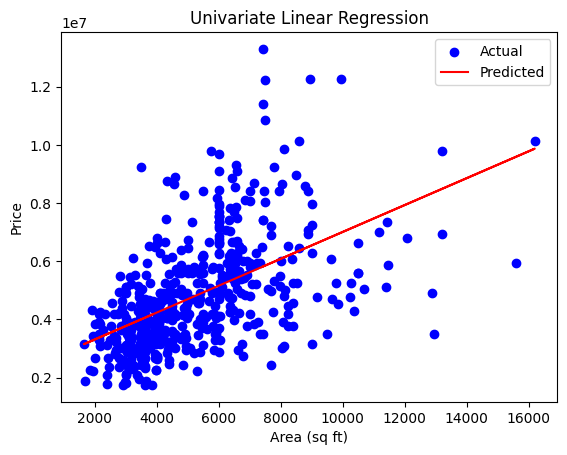

In [ ]:
# Use just 'area' feature
x_uni = df[['area']].values
y_uni = df['price'].values.reshape(-1, 1)

# Normalize and add bias
sc_uni = StandardScaler()
x_scaled = sc_uni.fit_transform(x_uni)
x_scaled = np.c_[np.ones((x_scaled.shape[0], 1)), x_scaled]

theta_uni, _ = gradient_descent(x_scaled, y_uni, alpha=0.01, epochs=10000)
pred_uni = x_scaled @ theta_uni
r2_uni = r2_score(y_uni, pred_uni)

print(f"Univariate Hypothesis: h(x) = {theta_uni[0][0]:.2f} + {theta_uni[1][0]:.2f} * area")
print(f"R² Score: {r2_uni:.4f} ({r2_uni * 100:.2f}% accuracy)")

# Plot
plt.scatter(x_uni, y_uni, color='blue', label='Actual')
plt.plot(x_uni, pred_uni, color='red', label='Predicted')
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")
plt.title("Univariate Linear Regression")
plt.legend()
plt.show()
